# 03 - ExtraTrees Robust Modeling with Target-Specific Feature Sets and Controlled Validation

## Objective

This notebook is a modified version of the first ExtraTrees modeling baseline.

It adds three important improvements:

1. **Best feature set selection per target** instead of using one global feature set for all outputs.
2. **Challenge constraints loading** from `inverse_design/constraints.json`.
3. **Controlled / stress validation** to evaluate robustness on regimes that are important for the challenge, especially:
   - low gravity and high gravity regimes,
   - high energy / high coupling / atmosphere extremes,
   - training rows close to the inverse-design target zone: `96 <= P80 <= 101` and `R95 <= 175`.

The goal is not final optimization yet.  
The goal is to understand whether the current robust ExtraTrees model is reliable enough before moving to gradient boosting models.

## 1. Imports and Project Paths

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

FORWARD_DIR = PROJECT_ROOT / "data" / "raw" / "forward_prediction"
INVERSE_DIR = PROJECT_ROOT / "data" / "raw" / "inverse_design"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
SUBMISSIONS_DIR = OUTPUTS_DIR / "submissions"
MODELS_DIR = OUTPUTS_DIR / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"

for path in [PROCESSED_DIR, SUBMISSIONS_DIR, MODELS_DIR, REPORTS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Forward data directory:", FORWARD_DIR)
print("Inverse design directory:", INVERSE_DIR)
print("Processed directory:", PROCESSED_DIR)
print("Submissions directory:", SUBMISSIONS_DIR)

Project root: /home/alouiyaz/projects/boom-challenge-ejecta-prediction
Forward data directory: /home/alouiyaz/projects/boom-challenge-ejecta-prediction/data/raw/forward_prediction
Inverse design directory: /home/alouiyaz/projects/boom-challenge-ejecta-prediction/data/raw/inverse_design
Processed directory: /home/alouiyaz/projects/boom-challenge-ejecta-prediction/data/processed
Submissions directory: /home/alouiyaz/projects/boom-challenge-ejecta-prediction/outputs/submissions


## 2. Load Challenge Constraints

The `constraints.json` file is used by the optional inverse-design task.

It contains:

- output constraints:
  - `p80_min`
  - `p80_max`
  - `r95_max`
- input bounds for generated design scenarios.

In this notebook, we do **not** generate inverse-design candidates yet.  
We use this file to evaluate whether our model is reliable near the target region.

In [2]:
constraints_path = INVERSE_DIR / "constraints.json"

if not constraints_path.exists():
    # Fallback path useful only if the file was copied next to the notebook manually.
    fallback_path = PROJECT_ROOT / "constraints.json"
    if fallback_path.exists():
        constraints_path = fallback_path

print("Constraints path:", constraints_path)

with open(constraints_path, "r") as f:
    constraints_data = json.load(f)

output_constraints = constraints_data["constraints"]
input_bounds = constraints_data["input_bounds"]

print("Output constraints:")
display(pd.DataFrame([output_constraints]))

print("Input bounds:")
display(pd.DataFrame(input_bounds).T)

Constraints path: /home/alouiyaz/projects/boom-challenge-ejecta-prediction/data/raw/inverse_design/constraints.json
Output constraints:


,p80_min,p80_max,r95_max
0,96.0,101.0,175.0


Input bounds:


,min,max
energy,0.500000,5.000000
angle_rad,0.261799,1.570796
coupling,0.200000,1.700000
strength,0.400000,4.200000
porosity,0.000000,0.330000
gravity,1.020000,10.470000
atmosphere,0.000000,1.000000
shape_factor,0.700000,1.500000


## 3. Load Data and Define Columns

In [3]:
input_cols = [
    "energy",
    "angle_rad",
    "coupling",
    "strength",
    "porosity",
    "gravity",
    "atmosphere",
    "shape_factor",
]

target_cols = [
    "P80",
    "fines_frac",
    "oversize_frac",
    "R95",
    "R50_fines",
    "R50_oversize",
]

fragmentation_targets = ["P80", "fines_frac", "oversize_frac"]
distance_targets = ["R95", "R50_fines", "R50_oversize"]

raw_train = pd.read_csv(FORWARD_DIR / "train.csv")[input_cols]
raw_test = pd.read_csv(FORWARD_DIR / "test.csv")[input_cols]
y = pd.read_csv(FORWARD_DIR / "train_labels.csv")[target_cols]
submission_template = pd.read_csv(FORWARD_DIR / "prediction_submission_template.csv")

print("Raw train:", raw_train.shape)
print("Raw test:", raw_test.shape)
print("Targets:", y.shape)

display(raw_train.head())
display(y.head())

Raw train: (2930, 8)
Raw test: (492, 8)
Targets: (2930, 6)


,energy,angle_rad,coupling,strength,porosity,gravity,atmosphere,shape_factor
0,3.826405,0.818303,0.861258,1.305809,0.337215,3.71,0.781263,0.784028
1,2.828754,1.193036,0.561245,3.494501,0.058029,1.62,0.136205,0.922737
2,3.068907,0.605872,0.948860,1.366386,0.315632,3.71,0.774704,0.954922
3,2.700574,1.073708,0.713705,3.599419,0.033062,1.62,0.144204,0.932911
4,3.484022,0.863568,1.237205,1.996742,0.278207,9.81,0.414620,1.260855


,P80,fines_frac,oversize_frac,R95,R50_fines,R50_oversize
0,76.972350,0.184728,0.016671,198.938699,175.527939,76.235779
1,269.057465,0.000622,0.916734,239.268477,447.157838,141.894047
2,104.070923,0.070343,0.094438,192.986417,189.286407,84.235774
3,257.618403,0.001026,0.880122,289.289693,500.000028,169.866473
4,111.717167,0.058576,0.136166,94.229304,97.614864,42.928393


## 4. Physics-Inspired Feature Engineering

The features are **proxies**, not exact physics equations.  
The dataset does not include projectile mass, projectile diameter, velocity, explicit material class, or impact location.

The purpose of these features is to help the model learn:

- energy transfer,
- impact angle decomposition,
- material fragility and resistance,
- gravity-scaled travel distance,
- atmosphere / drag effects,
- discrete regimes observed during EDA.

In [4]:
def add_physics_features(X: pd.DataFrame) -> pd.DataFrame:
    X = X.copy()
    eps = 1e-9

    # 1. Energy transfer features
    X["effective_energy"] = X["energy"] * X["coupling"]
    X["log_energy"] = np.log1p(X["energy"])
    X["log_effective_energy"] = np.log1p(X["effective_energy"])

    # 2. Angle decomposition
    X["sin_angle"] = np.sin(X["angle_rad"])
    X["cos_angle"] = np.cos(X["angle_rad"])
    X["tan_angle"] = np.tan(X["angle_rad"])

    X["horizontal_energy"] = X["effective_energy"] * X["cos_angle"]
    X["vertical_energy"] = X["effective_energy"] * X["sin_angle"]
    X["vertical_horizontal_ratio"] = X["vertical_energy"] / (X["horizontal_energy"] + eps)

    # 3. Material / fragmentation proxies
    X["energy_per_strength"] = X["energy"] / (X["strength"] + eps)
    X["effective_energy_per_strength"] = X["effective_energy"] / (X["strength"] + eps)
    X["material_resistance_index"] = X["strength"] * (1 - X["porosity"])
    X["fragmentation_index"] = X["effective_energy"] * X["porosity"] / (X["strength"] + eps)
    X["coupling_porosity"] = X["coupling"] * X["porosity"]
    X["coupling_atmosphere"] = X["coupling"] * X["atmosphere"]
    X["porosity_strength"] = X["porosity"] * X["strength"]

    # 4. Gravity and distance features
    X["energy_per_gravity"] = X["energy"] / (X["gravity"] + eps)
    X["effective_energy_per_gravity"] = X["effective_energy"] / (X["gravity"] + eps)
    X["horizontal_energy_per_gravity"] = X["horizontal_energy"] / (X["gravity"] + eps)
    X["vertical_energy_per_gravity"] = X["vertical_energy"] / (X["gravity"] + eps)

    # 5. Atmosphere and drag proxies
    X["drag_proxy"] = X["atmosphere"] * X["shape_factor"]
    X["drag_per_gravity"] = X["drag_proxy"] / (X["gravity"] + eps)
    X["atmosphere_shape_energy"] = X["atmosphere"] * X["shape_factor"] * X["effective_energy"]
    X["atmosphere_per_gravity"] = X["atmosphere"] / (X["gravity"] + eps)

    # 6. Pi-like scaling proxies inspired by dimensional analysis
    X["pi_gravity_proxy"] = (X["gravity"] * X["coupling"]) / (X["energy"] + eps)
    X["pi_strength_proxy"] = X["strength"] / (X["gravity"] * X["coupling"] + eps)
    X["pi_atmosphere_proxy"] = X["atmosphere"] / (X["gravity"] * X["coupling"] + eps)

    # 7. Regime indicators based on separated EDA ranges
    X["porosity_regime"] = (X["porosity"] > 0.15).astype(int)
    X["strength_regime"] = (X["strength"] > 2.6).astype(int)
    X["angle_regime"] = (X["angle_rad"] > 0.95).astype(int)
    X["atm_regime"] = (X["atmosphere"] > 0.30).astype(int)

    X["regime_combo"] = (
        X["porosity_regime"] * 8
        + X["strength_regime"] * 4
        + X["angle_regime"] * 2
        + X["atm_regime"]
    )

    # 8. Additional cross-regime proxies
    X["scaled_energy"] = X["effective_energy"] / (
        X["strength"] * np.sqrt(X["gravity"]) + eps
    )

    X["fragility"] = X["porosity"] / (X["strength"] + eps)

    X["range_proxy"] = (
        X["effective_energy"] * (X["cos_angle"] ** 2)
    ) / (X["gravity"] * X["strength"] + eps)

    X["energy_sin_angle"] = X["energy"] * X["sin_angle"]
    X["momentum_proxy"] = X["effective_energy"] * X["sin_angle"]

    # Risk-controlled atmosphere ratio.
    # We use 1e-3 instead of eps because test atmosphere can be very close to zero.
    X["coupling_per_atm_clipped"] = X["coupling"] / (X["atmosphere"] + 1e-3)
    X["log_coupling_per_atm"] = np.log1p(X["coupling_per_atm_clipped"])

    X["retention_factor"] = X["atmosphere"] * X["drag_proxy"] / (X["energy"] + eps)

    return X


X_fe_train = add_physics_features(raw_train)
X_fe_test = add_physics_features(raw_test)

print("X_fe_train:", X_fe_train.shape)
print("X_fe_test:", X_fe_test.shape)

display(X_fe_train.head())

X_fe_train: (2930, 48)
X_fe_test: (492, 48)


,energy,angle_rad,coupling,strength,porosity,gravity,atmosphere,shape_factor,effective_energy,log_energy,log_effective_energy,sin_angle,cos_angle,tan_angle,horizontal_energy,vertical_energy,vertical_horizontal_ratio,energy_per_strength,effective_energy_per_strength,material_resistance_index,fragmentation_index,coupling_porosity,coupling_atmosphere,porosity_strength,energy_per_gravity,effective_energy_per_gravity,horizontal_energy_per_gravity,vertical_energy_per_gravity,drag_proxy,drag_per_gravity,atmosphere_shape_energy,atmosphere_per_gravity,pi_gravity_proxy,pi_strength_proxy,pi_atmosphere_proxy,porosity_regime,strength_regime,angle_regime,atm_regime,regime_combo,scaled_energy,fragility,range_proxy,energy_sin_angle,momentum_proxy,coupling_per_atm_clipped,log_coupling_per_atm,retention_factor
0,3.826405,0.818303,0.861258,1.305809,0.337215,3.71,0.781263,0.784028,3.295522,1.574102,1.457573,0.729987,0.683461,1.068074,2.252360,2.405689,1.068074,2.930295,2.523740,0.865470,0.851043,0.290429,0.672869,0.440338,1.031376,0.888281,0.607105,0.648434,0.612532,0.165103,2.018613,0.210583,0.835057,0.408670,0.244506,1,0,0,1,9,1.310260,0.258242,0.317759,2.793226,2.405689,1.100982,0.742405,0.125065
1,2.828754,1.193036,0.561245,3.494501,0.058029,1.62,0.136205,0.922737,1.587625,1.342539,0.950740,0.929493,0.368839,2.520048,0.585579,1.475686,2.520048,0.809487,0.454321,3.291717,0.026364,0.032569,0.076445,0.202784,1.746145,0.980015,0.361468,0.910918,0.125682,0.077581,0.199535,0.084077,0.321420,3.843416,0.149805,0,1,1,0,6,0.356948,0.016606,0.038152,2.629307,1.475686,4.090551,1.627386,0.006052
2,3.068907,0.605872,0.948860,1.366386,0.315632,3.71,0.774704,0.954922,2.911963,1.403374,1.364039,0.569479,0.822006,0.692792,2.393651,1.658301,0.692792,2.246003,2.131142,0.935111,0.672656,0.299490,0.735085,0.431275,0.827199,0.784896,0.645189,0.446981,0.739782,0.199402,2.154217,0.208815,1.147076,0.388148,0.220069,1,0,0,1,9,1.106434,0.230997,0.388140,1.747677,1.658301,1.223225,0.798959,0.186748
3,2.700574,1.073708,0.713705,3.599419,0.033062,1.62,0.144204,0.932911,1.927413,1.308488,1.074119,0.878975,0.476868,1.843224,0.919122,1.694147,1.843224,0.750280,0.535479,3.480414,0.017704,0.023597,0.102919,0.119005,1.667021,1.189761,0.567359,1.045770,0.134530,0.083043,0.259294,0.089015,0.428132,3.113140,0.124722,0,1,1,0,6,0.420712,0.009185,0.075166,2.373736,1.694147,4.915185,1.777523,0.007184
4,3.484022,0.863568,1.237205,1.996742,0.278207,9.81,0.414620,1.260855,4.310448,1.500520,1.669676,0.760166,0.649729,1.169972,2.800625,3.276654,1.169972,1.744854,2.158741,1.441234,0.600577,0.344199,0.512970,0.555508,0.355150,0.439393,0.285487,0.334012,0.522776,0.053290,2.253399,0.042265,3.483611,0.164517,0.034162,1,0,0,1,9,0.689233,0.139331,0.092896,2.648433,3.276654,2.976766,1.380469,0.062214


## 5. Basic Safety Checks

In [5]:
def check_modeling_matrix(X: pd.DataFrame, name: str) -> pd.DataFrame:
    numeric = X.select_dtypes(include=[np.number])
    report = pd.DataFrame({
        "dtype": X.dtypes,
        "missing_count": X.isna().sum(),
        "inf_count": np.isinf(numeric).sum().reindex(X.columns, fill_value=0),
        "n_unique": X.nunique(),
    })

    print(f"\n{name}")
    print("Shape:", X.shape)
    print("Total missing:", int(report["missing_count"].sum()))
    print("Total infinite:", int(report["inf_count"].sum()))
    print("Non-numeric columns:", [c for c in X.columns if c not in numeric.columns])

    return report

quality_train = check_modeling_matrix(X_fe_train, "X_fe_train")
quality_test = check_modeling_matrix(X_fe_test, "X_fe_test")

assert X_fe_train.shape[0] == y.shape[0], "X and y row counts do not match."
assert X_fe_train.columns.tolist() == X_fe_test.columns.tolist(), "Train and test feature columns do not match."

display(quality_train.sort_values(["missing_count", "inf_count"], ascending=False).head(10))


X_fe_train
Shape: (2930, 48)
Total missing: 0
Total infinite: 0
Non-numeric columns: []

X_fe_test
Shape: (492, 48)
Total missing: 0
Total infinite: 0
Non-numeric columns: []


,dtype,missing_count,inf_count,n_unique
energy,float64,0,0,2930
angle_rad,float64,0,0,2930
coupling,float64,0,0,2930
strength,float64,0,0,2930
porosity,float64,0,0,2930
gravity,float64,0,0,3
atmosphere,float64,0,0,2930
shape_factor,float64,0,0,2930
effective_energy,float64,0,0,2930
log_energy,float64,0,0,2930


## 6. Train/Test and Constraint Bounds Coverage

This section compares:

- training ranges,
- scoring test ranges,
- inverse-design allowed bounds from `constraints.json`.

This is important because tree-based models are weak extrapolators.  
If the allowed inverse-design bounds are much wider than the training distribution, generated scenarios must be selected carefully.

In [6]:
coverage_rows = []

for col in input_cols:
    train_min, train_max = raw_train[col].min(), raw_train[col].max()
    test_min, test_max = raw_test[col].min(), raw_test[col].max()
    bound_min, bound_max = input_bounds[col]["min"], input_bounds[col]["max"]

    coverage_rows.append({
        "feature": col,
        "train_min": train_min,
        "train_max": train_max,
        "test_min": test_min,
        "test_max": test_max,
        "constraint_min": bound_min,
        "constraint_max": bound_max,
        "test_below_train": test_min < train_min,
        "test_above_train": test_max > train_max,
        "constraint_below_train": bound_min < train_min,
        "constraint_above_train": bound_max > train_max,
    })

coverage_df = pd.DataFrame(coverage_rows)
display(coverage_df)

,feature,train_min,train_max,test_min,test_max,constraint_min,constraint_max,test_below_train,test_above_train,constraint_below_train,constraint_above_train
0,energy,2.601520,4.596577,3.014554,4.696348,0.500000,5.000000,False,True,True,True
1,angle_rad,0.524044,1.308300,0.700266,1.213174,0.261799,1.570796,False,False,True,True
2,coupling,0.400526,1.599823,0.200334,1.691957,0.200000,1.700000,True,True,True,True
3,strength,0.810376,3.799996,0.900823,4.193536,0.400000,4.200000,False,True,True,True
4,porosity,0.000013,0.349741,0.080113,0.328892,0.000000,0.330000,False,False,True,False
5,gravity,1.620000,9.810000,1.020000,10.470000,1.020000,10.470000,True,True,True,True
6,atmosphere,0.050157,0.849873,0.002391,0.999355,0.000000,1.000000,True,True,True,True
7,shape_factor,0.750093,1.349924,0.703532,1.495898,0.700000,1.500000,True,True,True,True


## 7. Define Feature Sets

We compare multiple feature sets.  
Later, we select the best feature set **per target**, not globally.

In [7]:
raw_features = input_cols.copy()

core_physics_features = raw_features + [
    "effective_energy",
    "log_energy",
    "log_effective_energy",
    "sin_angle",
    "cos_angle",
    "tan_angle",
    "horizontal_energy",
    "vertical_energy",
    "vertical_horizontal_ratio",
    "energy_per_strength",
    "effective_energy_per_strength",
    "material_resistance_index",
    "fragmentation_index",
    "coupling_porosity",
    "coupling_atmosphere",
    "porosity_strength",
    "energy_per_gravity",
    "effective_energy_per_gravity",
    "horizontal_energy_per_gravity",
    "vertical_energy_per_gravity",
    "drag_proxy",
    "drag_per_gravity",
    "atmosphere_shape_energy",
    "atmosphere_per_gravity",
]

extended_physics_features = core_physics_features + [
    "pi_gravity_proxy",
    "pi_strength_proxy",
    "pi_atmosphere_proxy",
    "scaled_energy",
    "fragility",
    "range_proxy",
    "energy_sin_angle",
    "momentum_proxy",
    "coupling_per_atm_clipped",
    "log_coupling_per_atm",
    "retention_factor",
]

regime_features = extended_physics_features + [
    "porosity_regime",
    "strength_regime",
    "angle_regime",
    "atm_regime",
    "regime_combo",
]

fragmentation_features = raw_features + [
    "effective_energy",
    "log_effective_energy",
    "sin_angle",
    "cos_angle",
    "horizontal_energy",
    "vertical_energy",
    "energy_per_strength",
    "effective_energy_per_strength",
    "material_resistance_index",
    "fragmentation_index",
    "coupling_porosity",
    "coupling_atmosphere",
    "porosity_strength",
    "drag_proxy",
    "atmosphere_shape_energy",
    "pi_strength_proxy",
    "pi_atmosphere_proxy",
    "scaled_energy",
    "fragility",
    "energy_sin_angle",
    "momentum_proxy",
    "porosity_regime",
    "strength_regime",
    "angle_regime",
    "atm_regime",
    "regime_combo",
]

distance_features = raw_features + [
    "effective_energy",
    "log_effective_energy",
    "sin_angle",
    "cos_angle",
    "horizontal_energy",
    "vertical_energy",
    "energy_per_gravity",
    "effective_energy_per_gravity",
    "horizontal_energy_per_gravity",
    "vertical_energy_per_gravity",
    "drag_proxy",
    "drag_per_gravity",
    "atmosphere_shape_energy",
    "atmosphere_per_gravity",
    "pi_gravity_proxy",
    "pi_atmosphere_proxy",
    "scaled_energy",
    "range_proxy",
    "energy_sin_angle",
    "momentum_proxy",
    "porosity_regime",
    "strength_regime",
    "angle_regime",
    "atm_regime",
    "regime_combo",
]

def clean_feature_list(features, X):
    seen = set()
    out = []
    for f in features:
        if f in X.columns and f not in seen:
            out.append(f)
            seen.add(f)
    return out

core_physics_features = clean_feature_list(core_physics_features, X_fe_train)
extended_physics_features = clean_feature_list(extended_physics_features, X_fe_train)
regime_features = clean_feature_list(regime_features, X_fe_train)
fragmentation_features = clean_feature_list(fragmentation_features, X_fe_train)
distance_features = clean_feature_list(distance_features, X_fe_train)
full_features = X_fe_train.columns.tolist()

feature_sets = {
    "raw": raw_features,
    "core_physics": core_physics_features,
    "extended_physics": extended_physics_features,
    "extended_plus_regimes": regime_features,
    "full_features": full_features,
}

feature_set_summary = pd.DataFrame({
    "feature_set": list(feature_sets.keys()),
    "n_features": [len(v) for v in feature_sets.values()],
})
display(feature_set_summary)

print("Fragmentation-specific features:", len(fragmentation_features))
print("Distance-specific features:", len(distance_features))

,feature_set,n_features
0,raw,8
1,core_physics,32
2,extended_physics,43
3,extended_plus_regimes,48
4,full_features,48


Fragmentation-specific features: 34
Distance-specific features: 33


## 8. Metrics, Clipping and Model Definition

In [8]:
def regression_metrics(y_true, y_pred, target_name=None):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    out = {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
    }

    if target_name is not None:
        target_std = y[target_name].std()
        out["normalized_MAE"] = mae / (target_std + 1e-9)

    return out


def clip_predictions(preds: np.ndarray, target: str) -> np.ndarray:
    preds = np.asarray(preds).copy()

    if target in ["fines_frac", "oversize_frac"]:
        preds = np.clip(preds, 0, 1)
    else:
        preds = np.clip(preds, 0, None)

    return preds


def build_extratrees_model(random_state=42):
    return ExtraTreesRegressor(
        n_estimators=800,
        max_features="sqrt",
        min_samples_leaf=2,
        random_state=random_state,
        n_jobs=-1,
    )

## 9. Cross-Validation Functions

In [9]:
def cross_validate_target_model(
    X: pd.DataFrame,
    y: pd.DataFrame,
    target: str,
    features: list,
    n_splits: int = 5,
    random_state: int = 42,
):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    fold_results = []
    oof_pred = np.zeros(len(y))

    for fold, (train_idx, valid_idx) in enumerate(kf.split(X), start=1):
        X_train = X.iloc[train_idx][features]
        X_valid = X.iloc[valid_idx][features]
        y_train = y.iloc[train_idx][target]
        y_valid = y.iloc[valid_idx][target]

        model = build_extratrees_model(random_state=random_state + fold)
        model.fit(X_train, y_train)

        pred = model.predict(X_valid)
        pred = clip_predictions(pred, target)
        oof_pred[valid_idx] = pred

        metrics = regression_metrics(y_valid, pred, target_name=target)
        metrics["fold"] = fold
        metrics["target"] = target
        metrics["n_features"] = len(features)
        fold_results.append(metrics)

    fold_results_df = pd.DataFrame(fold_results)

    overall_metrics = regression_metrics(y[target], oof_pred, target_name=target)
    overall_metrics["fold"] = "OOF"
    overall_metrics["target"] = target
    overall_metrics["n_features"] = len(features)

    return fold_results_df, overall_metrics, oof_pred


def evaluate_feature_set(
    X: pd.DataFrame,
    y: pd.DataFrame,
    feature_set_name: str,
    feature_selector,
    n_splits: int = 5,
    random_state: int = 42,
):
    all_fold_results = []
    all_overall_results = []
    oof_predictions = {}

    for target in target_cols:
        features = feature_selector(target)

        fold_df, overall_metrics, oof_pred = cross_validate_target_model(
            X=X,
            y=y,
            target=target,
            features=features,
            n_splits=n_splits,
            random_state=random_state,
        )

        fold_df["feature_set"] = feature_set_name
        overall_metrics["feature_set"] = feature_set_name

        all_fold_results.append(fold_df)
        all_overall_results.append(overall_metrics)
        oof_predictions[target] = oof_pred

    fold_results = pd.concat(all_fold_results, ignore_index=True)
    overall_results = pd.DataFrame(all_overall_results)
    oof_predictions = pd.DataFrame(oof_predictions)

    return overall_results, fold_results, oof_predictions

## 10. Evaluate Feature Sets

In [10]:
results_map = {}
fold_results_map = {}
oof_map = {}

for feature_set_name, features in feature_sets.items():
    print(f"Evaluating feature set: {feature_set_name} ({len(features)} features)")

    overall_results, fold_results, oof_predictions = evaluate_feature_set(
        X=X_fe_train,
        y=y,
        feature_set_name=feature_set_name,
        feature_selector=lambda target, features=features: features,
    )

    results_map[feature_set_name] = overall_results
    fold_results_map[feature_set_name] = fold_results
    oof_map[feature_set_name] = oof_predictions

# Target-family-specific feature set
def target_family_feature_selector(target):
    if target in fragmentation_targets:
        return fragmentation_features
    return distance_features

print("Evaluating feature set: target_family_specific")
family_results, family_fold_results, family_oof = evaluate_feature_set(
    X=X_fe_train,
    y=y,
    feature_set_name="target_family_specific",
    feature_selector=target_family_feature_selector,
)

results_map["target_family_specific"] = family_results
fold_results_map["target_family_specific"] = family_fold_results
oof_map["target_family_specific"] = family_oof

comparison_results = pd.concat(results_map.values(), ignore_index=True)

display(comparison_results.sort_values(["target", "normalized_MAE"]))

for metric in ["MAE", "RMSE", "R2", "normalized_MAE"]:
    print(f"\nPivot table for {metric}")
    pivot = comparison_results.pivot(index="target", columns="feature_set", values=metric)
    display(pivot)

Evaluating feature set: raw (8 features)
Evaluating feature set: core_physics (32 features)
Evaluating feature set: extended_physics (43 features)
Evaluating feature set: extended_plus_regimes (48 features)
Evaluating feature set: full_features (48 features)
Evaluating feature set: target_family_specific


,MAE,RMSE,R2,normalized_MAE,fold,target,n_features,feature_set
30,7.711179,10.257217,0.975659,0.117271,OOF,P80,34,target_family_specific
6,7.737343,10.289710,0.975504,0.117669,OOF,P80,32,core_physics
12,7.779250,10.355143,0.975192,0.118306,OOF,P80,43,extended_physics
18,7.790379,10.376451,0.975089,0.118475,OOF,P80,48,extended_plus_regimes
24,7.804647,10.384029,0.975053,0.118692,OOF,P80,48,full_features
0,9.879243,12.858965,0.961744,0.150243,OOF,P80,8,raw
22,50.250298,78.434966,0.899044,0.203526,OOF,R50_fines,48,extended_plus_regimes
28,50.266583,78.449735,0.899006,0.203592,OOF,R50_fines,48,full_features
34,50.329516,78.446782,0.899014,0.203847,OOF,R50_fines,33,target_family_specific
16,50.347534,78.564305,0.898711,0.203920,OOF,R50_fines,43,extended_physics



Pivot table for MAE


feature_set,core_physics,extended_physics,extended_plus_regimes,full_features,raw,target_family_specific
target,,,,,,
P80,7.737343,7.779250,7.790379,7.804647,9.879243,7.711179
R50_fines,50.371332,50.347534,50.250298,50.266583,54.725985,50.329516
R50_oversize,22.590064,22.617973,22.549196,22.566936,24.592043,22.721199
R95,40.659546,40.503302,40.488282,40.574159,47.161152,41.404424
fines_frac,0.006524,0.006546,0.006596,0.006597,0.012449,0.006487
oversize_frac,0.026413,0.026542,0.026702,0.026678,0.039686,0.026200



Pivot table for RMSE


feature_set,core_physics,extended_physics,extended_plus_regimes,full_features,raw,target_family_specific
target,,,,,,
P80,10.289710,10.355143,10.376451,10.384029,12.858965,10.257217
R50_fines,78.543199,78.564305,78.434966,78.449735,83.167394,78.446782
R50_oversize,38.544662,38.569666,38.438910,38.438322,40.316531,38.564809
R95,67.458012,67.018031,66.977968,67.106449,77.547563,68.491023
fines_frac,0.014362,0.014427,0.014533,0.014545,0.024815,0.014240
oversize_frac,0.036120,0.036240,0.036481,0.036395,0.056841,0.035832



Pivot table for R2


feature_set,core_physics,extended_physics,extended_plus_regimes,full_features,raw,target_family_specific
target,,,,,,
P80,0.975504,0.975192,0.975089,0.975053,0.961744,0.975659
R50_fines,0.898766,0.898711,0.899044,0.899006,0.886495,0.899014
R50_oversize,0.873607,0.873443,0.874300,0.874304,0.861720,0.873475
R95,0.920002,0.921042,0.921136,0.920833,0.894282,0.917533
fines_frac,0.956156,0.955763,0.955108,0.955033,0.869122,0.956900
oversize_frac,0.990045,0.989979,0.989846,0.989893,0.975349,0.990204



Pivot table for normalized_MAE


feature_set,core_physics,extended_physics,extended_plus_regimes,full_features,raw,target_family_specific
target,,,,,,
P80,0.117669,0.118306,0.118475,0.118692,0.150243,0.117271
R50_fines,0.204016,0.203920,0.203526,0.203592,0.221654,0.203847
R50_oversize,0.208324,0.208582,0.207947,0.208111,0.226786,0.209534
R95,0.170449,0.169795,0.169732,0.170092,0.197705,0.173572
fines_frac,0.095093,0.095421,0.096145,0.096162,0.181457,0.094558
oversize_frac,0.072945,0.073304,0.073744,0.073678,0.109605,0.072357


## 11. Select Best Feature Set Per Target

Instead of forcing one feature set for all targets, we select the best feature set separately for each target using `normalized_MAE`.

This is important because the EDA showed two target families:

- fragmentation outcomes,
- landing-distance outcomes.

In [11]:
best_rows = (
    comparison_results
    .sort_values(["target", "normalized_MAE"])
    .groupby("target", as_index=False)
    .first()
)

best_feature_set_by_target = dict(zip(best_rows["target"], best_rows["feature_set"]))

print("Best feature set by target:")
display(best_rows[["target", "feature_set", "MAE", "RMSE", "R2", "normalized_MAE", "n_features"]])

print(best_feature_set_by_target)

Best feature set by target:


,target,feature_set,MAE,RMSE,R2,normalized_MAE,n_features
0,P80,target_family_specific,7.711179,10.257217,0.975659,0.117271,34
1,R50_fines,extended_plus_regimes,50.250298,78.434966,0.899044,0.203526,48
2,R50_oversize,extended_plus_regimes,22.549196,38.438910,0.874300,0.207947,48
3,R95,extended_plus_regimes,40.488282,66.977968,0.921136,0.169732,48
4,fines_frac,target_family_specific,0.006487,0.014240,0.956900,0.094558,34
5,oversize_frac,target_family_specific,0.026200,0.035832,0.990204,0.072357,34


{'P80': 'target_family_specific', 'R50_fines': 'extended_plus_regimes', 'R50_oversize': 'extended_plus_regimes', 'R95': 'extended_plus_regimes', 'fines_frac': 'target_family_specific', 'oversize_frac': 'target_family_specific'}


## 12. Build Selected OOF Predictions Per Target

This creates a final OOF prediction table by taking, for each target, the OOF predictions from its best feature set.

In [12]:
selected_oof = pd.DataFrame(index=y.index)

for target in target_cols:
    best_set = best_feature_set_by_target[target]
    selected_oof[target] = oof_map[best_set][target]

display(selected_oof.head())

selected_metrics = []
for target in target_cols:
    metrics = regression_metrics(y[target], selected_oof[target], target_name=target)
    metrics["target"] = target
    metrics["selected_feature_set"] = best_feature_set_by_target[target]
    selected_metrics.append(metrics)

selected_metrics_df = pd.DataFrame(selected_metrics)
display(selected_metrics_df.sort_values("normalized_MAE"))

,P80,fines_frac,oversize_frac,R95,R50_fines,R50_oversize
0,84.113964,0.150063,0.023944,304.157018,276.641056,131.031066
1,253.703768,0.000656,0.899496,300.796952,549.264585,181.529091
2,98.454506,0.089306,0.073738,252.327220,245.616338,114.448395
3,234.866659,0.001086,0.859177,315.403350,527.940568,187.503120
4,104.170772,0.077338,0.103913,92.158422,90.395037,40.939503


,MAE,RMSE,R2,normalized_MAE,target,selected_feature_set
2,0.026200,0.035832,0.990204,0.072357,oversize_frac,target_family_specific
1,0.006487,0.014240,0.956900,0.094558,fines_frac,target_family_specific
0,7.711179,10.257217,0.975659,0.117271,P80,target_family_specific
3,40.488282,66.977968,0.921136,0.169732,R95,extended_plus_regimes
4,50.250298,78.434966,0.899044,0.203526,R50_fines,extended_plus_regimes
5,22.549196,38.438910,0.874300,0.207947,R50_oversize,extended_plus_regimes


## 13. Error Analysis by Target

,target,selected_feature_set,MAE,Median_AE,P90_AE,P95_AE,Max_AE,Bias_mean_residual,R2
0,P80,target_family_specific,7.711179,5.946852,16.858204,21.748532,54.213116,-0.008502,0.975659
1,fines_frac,target_family_specific,0.006487,0.000635,0.019544,0.031649,0.158568,-0.000066,0.956900
2,oversize_frac,target_family_specific,0.026200,0.019166,0.058831,0.075833,0.181846,-0.000101,0.990204
3,R95,extended_plus_regimes,40.488282,20.826008,102.933259,149.215044,498.060737,-0.277394,0.921136
4,R50_fines,extended_plus_regimes,50.250298,27.138763,129.092999,175.049355,549.996096,-0.309918,0.899044
5,R50_oversize,extended_plus_regimes,22.549196,11.429620,55.926858,82.452303,348.671160,0.000712,0.874300


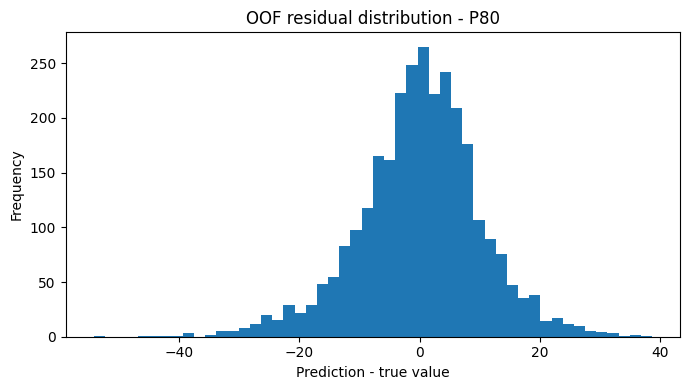

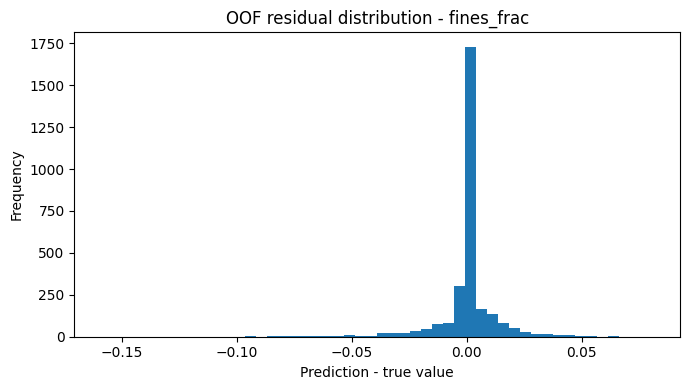

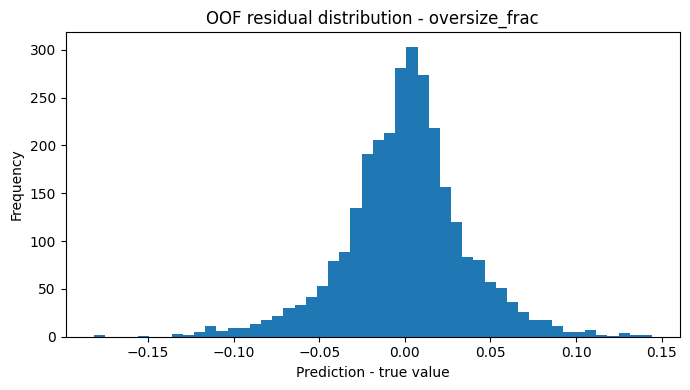

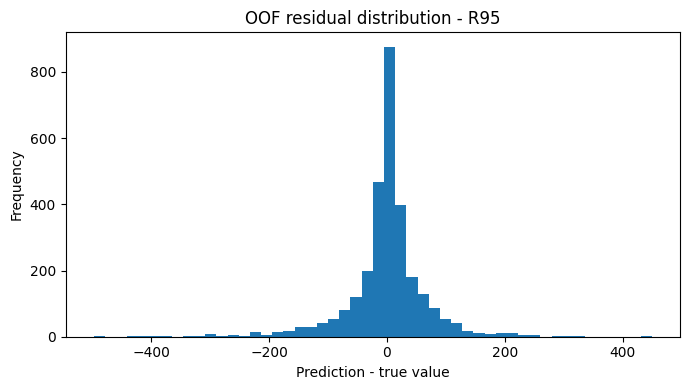

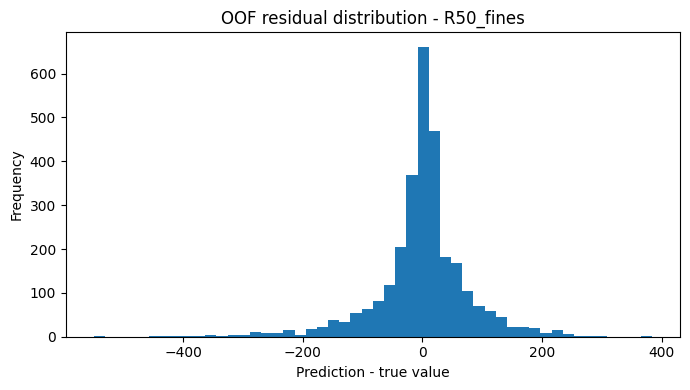

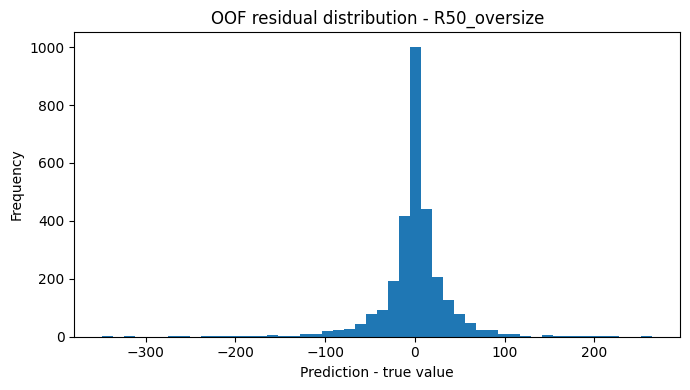

In [13]:
error_summary = []

for target in target_cols:
    residual = selected_oof[target] - y[target]
    abs_error = np.abs(residual)

    error_summary.append({
        "target": target,
        "selected_feature_set": best_feature_set_by_target[target],
        "MAE": abs_error.mean(),
        "Median_AE": np.median(abs_error),
        "P90_AE": np.percentile(abs_error, 90),
        "P95_AE": np.percentile(abs_error, 95),
        "Max_AE": abs_error.max(),
        "Bias_mean_residual": residual.mean(),
        "R2": r2_score(y[target], selected_oof[target]),
    })

error_summary_df = pd.DataFrame(error_summary)
display(error_summary_df)

for target in target_cols:
    plt.figure(figsize=(7, 4))
    residual = selected_oof[target] - y[target]
    plt.hist(residual, bins=50)
    plt.title(f"OOF residual distribution - {target}")
    plt.xlabel("Prediction - true value")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

## 14. Predicted vs True Plots

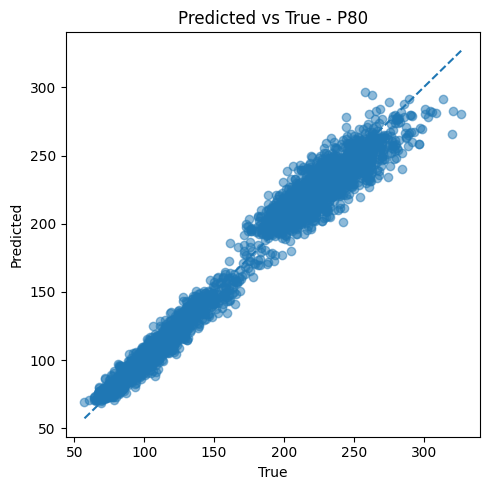

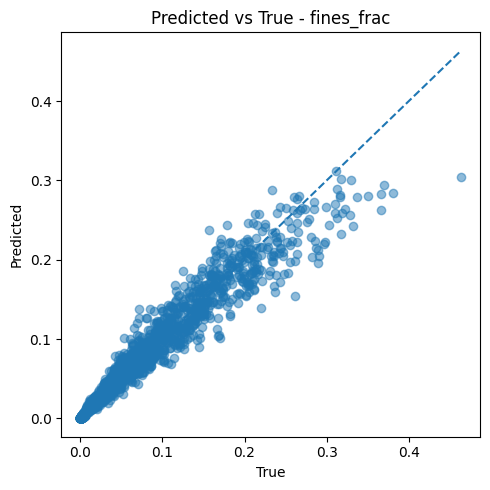

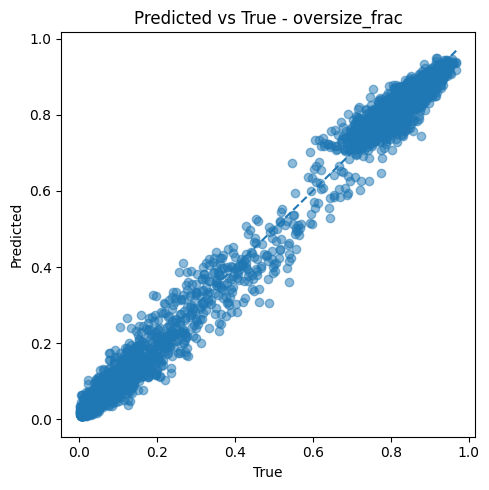

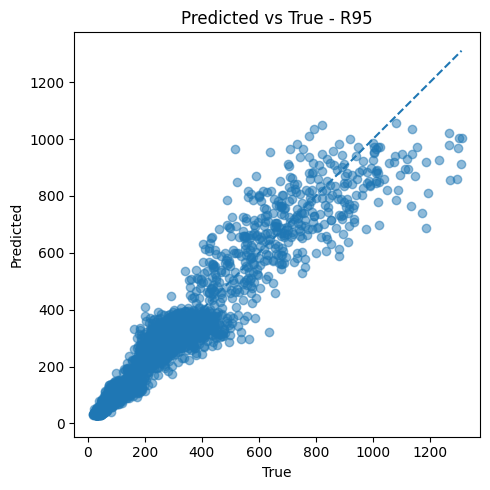

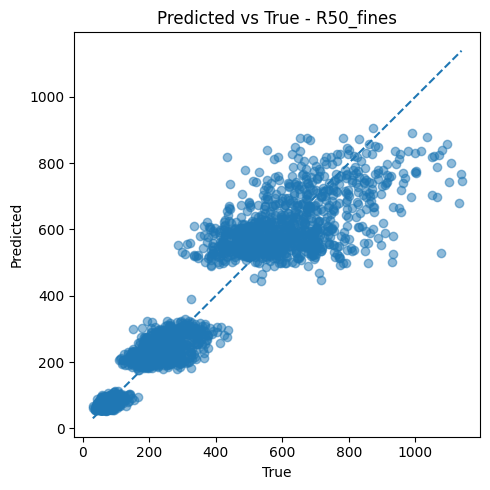

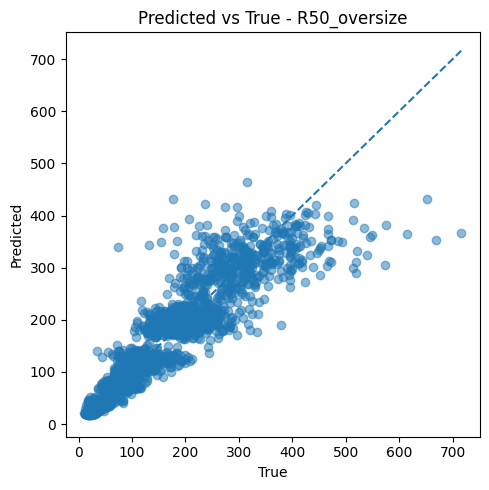

In [14]:
for target in target_cols:
    plt.figure(figsize=(5, 5))
    plt.scatter(y[target], selected_oof[target], alpha=0.5)

    min_val = min(y[target].min(), selected_oof[target].min())
    max_val = max(y[target].max(), selected_oof[target].max())

    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
    plt.title(f"Predicted vs True - {target}")
    plt.xlabel("True")
    plt.ylabel("Predicted")
    plt.tight_layout()
    plt.show()

## 15. Error Analysis by Gravity Regime

Gravity is the dominant driver for distance targets.  
This section computes both absolute and relative MAE by gravity level.

,gravity,n,MAE,Median_AE,true_mean,pred_mean,relative_MAE,target
0,1.62,990,7.514821,5.829020,172.057458,172.137717,0.043676,P80
1,3.71,1000,7.819317,6.139897,173.218872,173.091830,0.045141,P80
2,9.81,940,7.802943,6.025330,170.305048,170.329171,0.045817,P80
3,1.62,990,0.006480,0.000605,0.044202,0.044178,0.146608,fines_frac
4,3.71,1000,0.006160,0.000593,0.041332,0.041347,0.149027,fines_frac
5,9.81,940,0.006843,0.000721,0.046206,0.046009,0.148089,fines_frac
6,1.62,990,0.025412,0.018337,0.515164,0.515244,0.049327,oversize_frac
7,3.71,1000,0.026743,0.019813,0.519970,0.519718,0.051431,oversize_frac
8,9.81,940,0.026452,0.019474,0.505603,0.505473,0.052317,oversize_frac
9,1.62,990,79.692183,63.114891,504.102546,501.613256,0.158087,R95


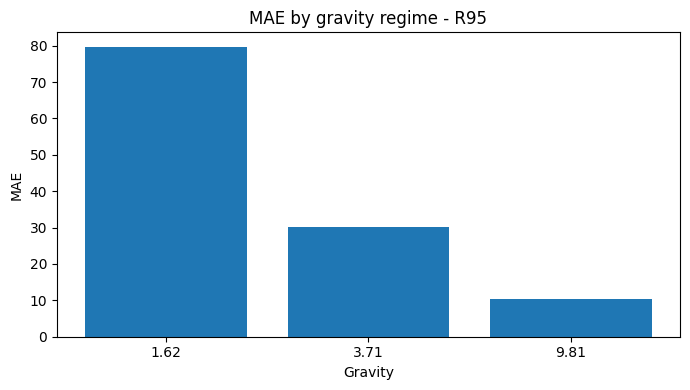

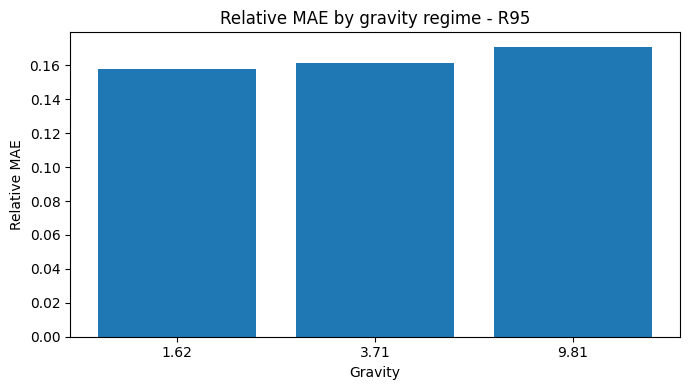

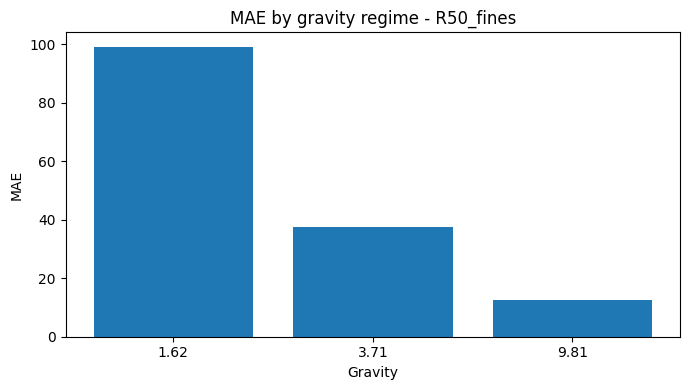

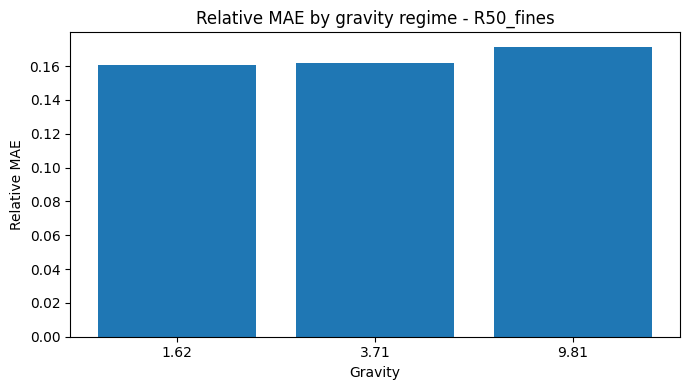

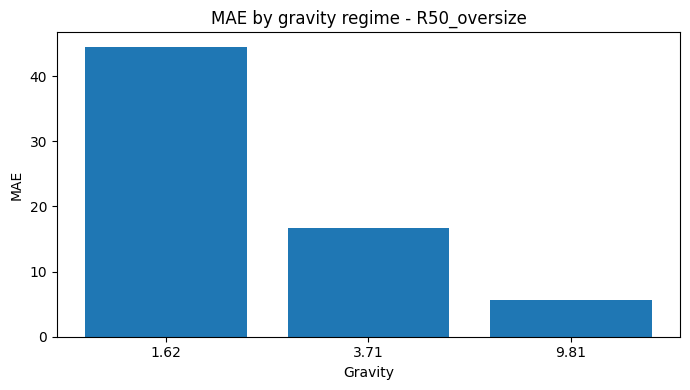

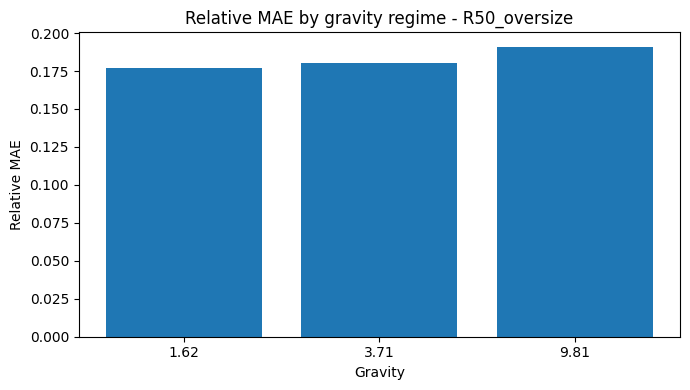

In [15]:
gravity_error_rows = []
analysis_df = raw_train.copy()

for target in target_cols:
    abs_error = np.abs(selected_oof[target] - y[target])

    temp = pd.DataFrame({
        "gravity": analysis_df["gravity"],
        "target": target,
        "abs_error": abs_error,
        "true_value": y[target],
        "prediction": selected_oof[target],
    })

    grouped = (
        temp.groupby("gravity")
        .agg(
            n=("abs_error", "size"),
            MAE=("abs_error", "mean"),
            Median_AE=("abs_error", "median"),
            true_mean=("true_value", "mean"),
            pred_mean=("prediction", "mean"),
        )
        .reset_index()
    )

    grouped["relative_MAE"] = grouped["MAE"] / (grouped["true_mean"].abs() + 1e-9)
    grouped["target"] = target
    gravity_error_rows.append(grouped)

gravity_error_df = pd.concat(gravity_error_rows, ignore_index=True)
display(gravity_error_df)

for target in distance_targets:
    temp = gravity_error_df[gravity_error_df["target"] == target]

    plt.figure(figsize=(7, 4))
    plt.bar(temp["gravity"].astype(str), temp["MAE"])
    plt.title(f"MAE by gravity regime - {target}")
    plt.xlabel("Gravity")
    plt.ylabel("MAE")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.bar(temp["gravity"].astype(str), temp["relative_MAE"])
    plt.title(f"Relative MAE by gravity regime - {target}")
    plt.xlabel("Gravity")
    plt.ylabel("Relative MAE")
    plt.tight_layout()
    plt.show()

## 16. Constraint-Zone Evaluation

The inverse-design objective requires:

- `96 <= P80 <= 101`
- `R95 <= 175`

This section evaluates whether OOF predictions are reliable for training rows that satisfy or are close to these constraints.

This does not solve inverse design yet.  
It only checks if the current surrogate model is accurate around the important target region.

In [16]:
p80_min = output_constraints["p80_min"]
p80_max = output_constraints["p80_max"]
r95_max = output_constraints["r95_max"]

true_feasible_mask = (
    (y["P80"] >= p80_min)
    & (y["P80"] <= p80_max)
    & (y["R95"] <= r95_max)
)

near_feasible_mask = (
    (y["P80"] >= p80_min - 10)
    & (y["P80"] <= p80_max + 10)
    & (y["R95"] <= r95_max + 50)
)

pred_feasible_mask = (
    (selected_oof["P80"] >= p80_min)
    & (selected_oof["P80"] <= p80_max)
    & (selected_oof["R95"] <= r95_max)
)

constraint_zone_summary = pd.DataFrame([
    {
        "zone": "true_feasible",
        "n_rows": int(true_feasible_mask.sum()),
        "percent_rows": true_feasible_mask.mean() * 100,
    },
    {
        "zone": "near_feasible",
        "n_rows": int(near_feasible_mask.sum()),
        "percent_rows": near_feasible_mask.mean() * 100,
    },
    {
        "zone": "predicted_feasible_by_oof",
        "n_rows": int(pred_feasible_mask.sum()),
        "percent_rows": pred_feasible_mask.mean() * 100,
    },
])

display(constraint_zone_summary)

def evaluate_mask_zone(mask, zone_name):
    rows = []
    if mask.sum() == 0:
        return pd.DataFrame([{"zone": zone_name, "target": "ALL", "message": "No rows in this zone"}])

    for target in ["P80", "R95"]:
        abs_error = np.abs(selected_oof.loc[mask, target] - y.loc[mask, target])
        rows.append({
            "zone": zone_name,
            "target": target,
            "n": int(mask.sum()),
            "MAE": abs_error.mean(),
            "Median_AE": np.median(abs_error),
            "P90_AE": np.percentile(abs_error, 90),
            "true_mean": y.loc[mask, target].mean(),
            "pred_mean": selected_oof.loc[mask, target].mean(),
        })
    return pd.DataFrame(rows)

constraint_zone_error_df = pd.concat([
    evaluate_mask_zone(true_feasible_mask, "true_feasible"),
    evaluate_mask_zone(near_feasible_mask, "near_feasible"),
], ignore_index=True)

display(constraint_zone_error_df)

# Precision-like / recall-like diagnostic for OOF feasible classification.
tp = int((true_feasible_mask & pred_feasible_mask).sum())
fp = int((~true_feasible_mask & pred_feasible_mask).sum())
fn = int((true_feasible_mask & ~pred_feasible_mask).sum())

precision_like = tp / (tp + fp + 1e-9)
recall_like = tp / (tp + fn + 1e-9)

feasibility_diagnostic = pd.DataFrame([{
    "true_positive": tp,
    "false_positive": fp,
    "false_negative": fn,
    "precision_like": precision_like,
    "recall_like": recall_like,
}])

display(feasibility_diagnostic)

,zone,n_rows,percent_rows
0,true_feasible,35,1.194539
1,near_feasible,213,7.269625
2,predicted_feasible_by_oof,39,1.331058


,zone,target,n,MAE,Median_AE,P90_AE,true_mean,pred_mean
0,true_feasible,P80,35,4.180041,4.783561,8.382471,98.532108,100.295979
1,true_feasible,R95,35,22.297445,19.144054,42.818570,91.437606,91.033208
2,near_feasible,P80,213,4.466408,3.813097,9.061188,99.053512,99.858218
3,near_feasible,R95,213,26.151818,16.594482,66.227970,112.279520,126.225034


,true_positive,false_positive,false_negative,precision_like,recall_like
0,13,26,22,0.333333,0.371429


## 17. Controlled / Stress Validation

Random KFold is useful but can be too optimistic when the test set contains out-of-distribution scenarios.

This section creates controlled validation slices:

- low gravity,
- medium gravity,
- high gravity,
- high energy,
- high coupling,
- low atmosphere,
- high atmosphere,
- high shape factor,
- near inverse-design zone.

For each slice, the model is trained on the remaining rows and evaluated on the selected stress slice.

This is stricter than random KFold and gives a better idea of robustness.

In [17]:
def get_feature_list_for_target_and_set(target, feature_set_name):
    if feature_set_name == "raw":
        return raw_features
    if feature_set_name == "core_physics":
        return core_physics_features
    if feature_set_name == "extended_physics":
        return extended_physics_features
    if feature_set_name == "extended_plus_regimes":
        return regime_features
    if feature_set_name == "full_features":
        return full_features
    if feature_set_name == "target_family_specific":
        return target_family_feature_selector(target)
    raise ValueError(f"Unknown feature set: {feature_set_name}")


stress_masks = {
    "low_gravity": raw_train["gravity"] == raw_train["gravity"].min(),
    "medium_gravity": raw_train["gravity"] == raw_train["gravity"].median(),
    "high_gravity": raw_train["gravity"] == raw_train["gravity"].max(),
    "high_energy_q90": raw_train["energy"] >= raw_train["energy"].quantile(0.90),
    "high_coupling_q90": raw_train["coupling"] >= raw_train["coupling"].quantile(0.90),
    "low_atmosphere_q10": raw_train["atmosphere"] <= raw_train["atmosphere"].quantile(0.10),
    "high_atmosphere_q90": raw_train["atmosphere"] >= raw_train["atmosphere"].quantile(0.90),
    "high_shape_factor_q90": raw_train["shape_factor"] >= raw_train["shape_factor"].quantile(0.90),
    "near_feasible_zone": near_feasible_mask,
}

stress_summary = pd.DataFrame([
    {"stress_slice": name, "n_valid_rows": int(mask.sum()), "percent_rows": mask.mean() * 100}
    for name, mask in stress_masks.items()
])
display(stress_summary)

,stress_slice,n_valid_rows,percent_rows
0,low_gravity,990,33.788396
1,medium_gravity,1000,34.129693
2,high_gravity,940,32.081911
3,high_energy_q90,293,10.000000
4,high_coupling_q90,293,10.000000
5,low_atmosphere_q10,293,10.000000
6,high_atmosphere_q90,293,10.000000
7,high_shape_factor_q90,293,10.000000
8,near_feasible_zone,213,7.269625


In [18]:
def controlled_holdout_evaluation(X, y, stress_masks, best_feature_set_by_target, min_valid_rows=30):
    rows = []

    for slice_name, valid_mask in stress_masks.items():
        valid_idx = np.where(valid_mask.values)[0]
        train_idx = np.where(~valid_mask.values)[0]

        if len(valid_idx) < min_valid_rows:
            print(f"Skipping {slice_name}: only {len(valid_idx)} validation rows.")
            continue

        for target in target_cols:
            feature_set_name = best_feature_set_by_target[target]
            features = get_feature_list_for_target_and_set(target, feature_set_name)

            model = build_extratrees_model(random_state=42)
            model.fit(X.iloc[train_idx][features], y.iloc[train_idx][target])

            pred = model.predict(X.iloc[valid_idx][features])
            pred = clip_predictions(pred, target)

            metrics = regression_metrics(y.iloc[valid_idx][target], pred, target_name=target)
            metrics.update({
                "stress_slice": slice_name,
                "target": target,
                "n_valid_rows": len(valid_idx),
                "feature_set": feature_set_name,
                "valid_true_mean": y.iloc[valid_idx][target].mean(),
                "valid_pred_mean": pred.mean(),
                "relative_MAE": metrics["MAE"] / (abs(y.iloc[valid_idx][target].mean()) + 1e-9),
            })

            rows.append(metrics)

    return pd.DataFrame(rows)


stress_validation_df = controlled_holdout_evaluation(
    X=X_fe_train,
    y=y,
    stress_masks=stress_masks,
    best_feature_set_by_target=best_feature_set_by_target,
)

display(stress_validation_df.sort_values(["target", "normalized_MAE"]))

,MAE,RMSE,R2,normalized_MAE,stress_slice,target,n_valid_rows,feature_set,valid_true_mean,valid_pred_mean,relative_MAE
36,5.033630,6.475075,0.942210,0.076551,high_atmosphere_q90,P80,293,target_family_specific,107.992333,107.450656,0.046611
42,5.037783,6.649878,0.944005,0.076614,high_shape_factor_q90,P80,293,target_family_specific,109.207447,108.800983,0.046130
24,5.058665,6.240951,0.783814,0.076932,high_coupling_q90,P80,293,target_family_specific,89.673152,91.314175,0.056412
18,5.138024,6.415049,0.909744,0.078139,high_energy_q90,P80,293,target_family_specific,99.377413,101.606680,0.051702
48,5.704409,6.980495,0.061438,0.086752,near_feasible_zone,P80,213,target_family_specific,99.053512,101.099689,0.057589
0,7.769470,10.297516,0.975446,0.118157,low_gravity,P80,990,target_family_specific,172.057458,171.815494,0.045156
6,8.024743,10.604084,0.973716,0.122040,medium_gravity,P80,1000,target_family_specific,173.218872,172.968356,0.046327
12,8.281892,10.765089,0.973474,0.125950,high_gravity,P80,940,target_family_specific,170.305048,172.320040,0.048630
30,9.828142,12.507720,0.746753,0.149465,low_atmosphere_q10,P80,293,target_family_specific,229.342674,230.142665,0.042854
52,28.878877,41.154229,0.336402,0.116966,near_feasible_zone,R50_fines,213,extended_plus_regimes,109.553139,126.999092,0.263606


## 18. Stress Validation Pivot Tables

These tables show where the model is robust and where it is fragile.

In [19]:
for metric in ["MAE", "relative_MAE", "R2"]:
    print(f"\nStress validation pivot: {metric}")
    pivot = stress_validation_df.pivot_table(
        index="stress_slice",
        columns="target",
        values=metric,
        aggfunc="mean",
    )
    display(pivot)

# Focus on the two inverse-design targets
focus = stress_validation_df[stress_validation_df["target"].isin(["P80", "R95"])]
display(focus.sort_values(["target", "relative_MAE"]))


Stress validation pivot: MAE


target,P80,R50_fines,R50_oversize,R95,fines_frac,oversize_frac
stress_slice,,,,,,
high_atmosphere_q90,5.033630,54.467863,29.049995,55.874798,0.013272,0.028393
high_coupling_q90,5.058665,58.595775,37.145846,63.860876,0.024731,0.019948
high_energy_q90,5.138024,60.308161,36.600128,63.037139,0.016523,0.028292
high_gravity,8.281892,156.442283,61.009809,119.431187,0.007522,0.028773
high_shape_factor_q90,5.037783,54.107470,29.267342,55.070229,0.012325,0.029273
low_atmosphere_q10,9.828142,49.412499,17.088923,28.795076,0.000251,0.021729
low_gravity,7.769470,374.795049,151.575834,294.035140,0.007270,0.030583
medium_gravity,8.024743,158.147685,64.833014,127.229591,0.006522,0.027205
near_feasible_zone,5.704409,28.878877,13.705277,29.724785,0.015529,0.033698



Stress validation pivot: relative_MAE


target,P80,R50_fines,R50_oversize,R95,fines_frac,oversize_frac
stress_slice,,,,,,
high_atmosphere_q90,0.046611,0.160197,0.182148,0.161139,0.147452,0.184778
high_coupling_q90,0.056412,0.164255,0.225240,0.162363,0.164824,0.391752
high_energy_q90,0.051702,0.158717,0.212351,0.159066,0.148518,0.272252
high_gravity,0.048630,2.155755,2.063052,1.993825,0.162797,0.056909
high_shape_factor_q90,0.046130,0.170646,0.198197,0.171950,0.137315,0.179224
low_atmosphere_q10,0.042854,0.172253,0.170533,0.169278,0.178515,0.025989
low_gravity,0.045156,0.606694,0.602269,0.583284,0.164469,0.059366
medium_gravity,0.046327,0.684360,0.698974,0.681520,0.157794,0.052320
near_feasible_zone,0.057589,0.263606,0.273118,0.264739,0.179274,0.456976



Stress validation pivot: R2


target,P80,R50_fines,R50_oversize,R95,fines_frac,oversize_frac
stress_slice,,,,,,
high_atmosphere_q90,0.942210,0.902799,0.867133,0.908249,0.925198,0.943107
high_coupling_q90,0.783814,0.909075,0.825697,0.912610,0.761168,0.717317
high_energy_q90,0.909744,0.899613,0.813994,0.904400,0.910983,0.875866
high_gravity,0.973474,-64.490822,-29.337134,-16.942146,0.946659,0.988910
high_shape_factor_q90,0.944005,0.888387,0.840119,0.894221,0.937161,0.942792
low_atmosphere_q10,0.746753,0.880568,0.881436,0.883356,0.813005,0.808910
low_gravity,0.975446,-6.101424,-2.611705,-1.065438,0.949757,0.987906
medium_gravity,0.973716,-8.281407,-4.415044,-1.771918,0.949606,0.989643
near_feasible_zone,0.061438,0.336402,0.361427,0.283006,0.433478,-0.449734


,MAE,RMSE,R2,normalized_MAE,stress_slice,target,n_valid_rows,feature_set,valid_true_mean,valid_pred_mean,relative_MAE
30,9.828142,12.507720,0.746753,0.149465,low_atmosphere_q10,P80,293,target_family_specific,229.342674,230.142665,0.042854
0,7.769470,10.297516,0.975446,0.118157,low_gravity,P80,990,target_family_specific,172.057458,171.815494,0.045156
42,5.037783,6.649878,0.944005,0.076614,high_shape_factor_q90,P80,293,target_family_specific,109.207447,108.800983,0.046130
6,8.024743,10.604084,0.973716,0.122040,medium_gravity,P80,1000,target_family_specific,173.218872,172.968356,0.046327
36,5.033630,6.475075,0.942210,0.076551,high_atmosphere_q90,P80,293,target_family_specific,107.992333,107.450656,0.046611
12,8.281892,10.765089,0.973474,0.125950,high_gravity,P80,940,target_family_specific,170.305048,172.320040,0.048630
18,5.138024,6.415049,0.909744,0.078139,high_energy_q90,P80,293,target_family_specific,99.377413,101.606680,0.051702
24,5.058665,6.240951,0.783814,0.076932,high_coupling_q90,P80,293,target_family_specific,89.673152,91.314175,0.056412
48,5.704409,6.980495,0.061438,0.086752,near_feasible_zone,P80,213,target_family_specific,99.053512,101.099689,0.057589
21,63.037139,95.975090,0.904400,0.264259,high_energy_q90,R95,293,extended_plus_regimes,396.296489,386.703838,0.159066


## 19. Feature Importance with Selected Feature Set Per Target


Top feature importances for P80 | feature set: target_family_specific


,feature,importance,target,feature_set
32,atm_regime,0.120288,P80,target_family_specific
29,porosity_regime,0.111619,P80,target_family_specific
33,regime_combo,0.107820,P80,target_family_specific
30,strength_regime,0.062950,P80,target_family_specific
31,angle_regime,0.060370,P80,target_family_specific
4,porosity,0.048325,P80,target_family_specific
16,material_resistance_index,0.039149,P80,target_family_specific
26,fragility,0.038503,P80,target_family_specific
6,atmosphere,0.036706,P80,target_family_specific
11,cos_angle,0.035160,P80,target_family_specific


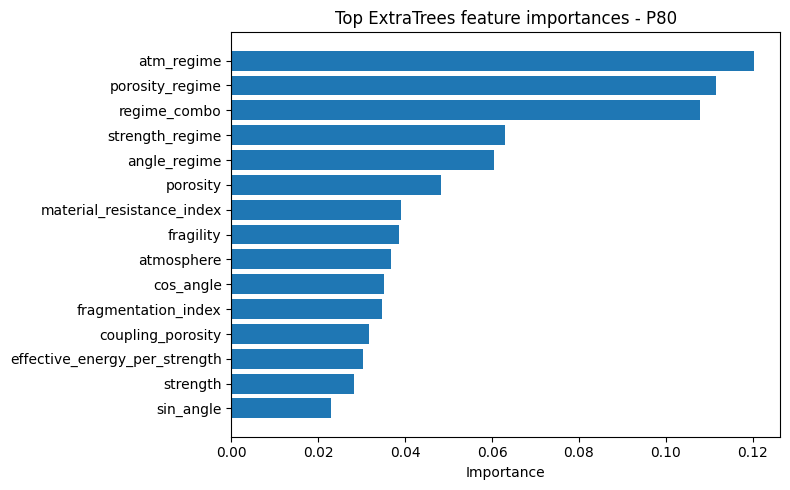


Top feature importances for fines_frac | feature set: target_family_specific


,feature,importance,target,feature_set
15,effective_energy_per_strength,0.125271,fines_frac,target_family_specific
17,fragmentation_index,0.112558,fines_frac,target_family_specific
3,strength,0.048776,fines_frac,target_family_specific
14,energy_per_strength,0.048423,fines_frac,target_family_specific
16,material_resistance_index,0.046275,fines_frac,target_family_specific
8,effective_energy,0.045971,fines_frac,target_family_specific
12,horizontal_energy,0.045587,fines_frac,target_family_specific
18,coupling_porosity,0.043959,fines_frac,target_family_specific
9,log_effective_energy,0.043177,fines_frac,target_family_specific
25,scaled_energy,0.041132,fines_frac,target_family_specific


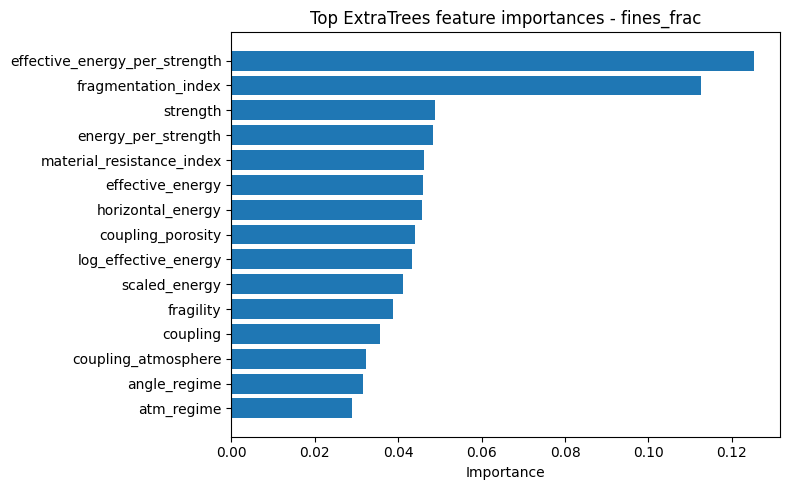


Top feature importances for oversize_frac | feature set: target_family_specific


,feature,importance,target,feature_set
31,angle_regime,0.108816,oversize_frac,target_family_specific
30,strength_regime,0.107411,oversize_frac,target_family_specific
32,atm_regime,0.089246,oversize_frac,target_family_specific
33,regime_combo,0.079400,oversize_frac,target_family_specific
29,porosity_regime,0.076540,oversize_frac,target_family_specific
16,material_resistance_index,0.057029,oversize_frac,target_family_specific
3,strength,0.041429,oversize_frac,target_family_specific
17,fragmentation_index,0.038216,oversize_frac,target_family_specific
4,porosity,0.037277,oversize_frac,target_family_specific
26,fragility,0.033957,oversize_frac,target_family_specific


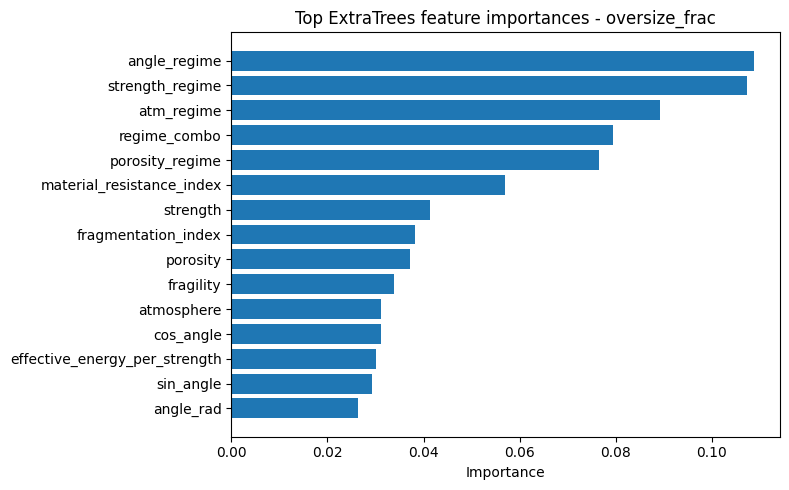


Top feature importances for R95 | feature set: extended_plus_regimes


,feature,importance,target,feature_set
5,gravity,0.134646,R95,extended_plus_regimes
24,energy_per_gravity,0.096228,R95,extended_plus_regimes
31,atmosphere_per_gravity,0.089975,R95,extended_plus_regimes
25,effective_energy_per_gravity,0.087479,R95,extended_plus_regimes
26,horizontal_energy_per_gravity,0.083741,R95,extended_plus_regimes
27,vertical_energy_per_gravity,0.069210,R95,extended_plus_regimes
37,range_proxy,0.067026,R95,extended_plus_regimes
35,scaled_energy,0.060678,R95,extended_plus_regimes
29,drag_per_gravity,0.052148,R95,extended_plus_regimes
34,pi_atmosphere_proxy,0.029846,R95,extended_plus_regimes


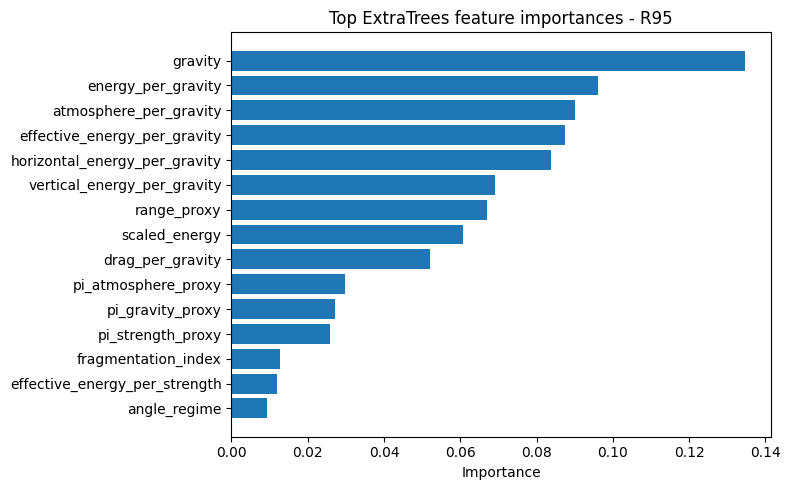


Top feature importances for R50_fines | feature set: extended_plus_regimes


,feature,importance,target,feature_set
5,gravity,0.203050,R50_fines,extended_plus_regimes
24,energy_per_gravity,0.147620,R50_fines,extended_plus_regimes
25,effective_energy_per_gravity,0.080751,R50_fines,extended_plus_regimes
27,vertical_energy_per_gravity,0.080453,R50_fines,extended_plus_regimes
31,atmosphere_per_gravity,0.066181,R50_fines,extended_plus_regimes
26,horizontal_energy_per_gravity,0.059632,R50_fines,extended_plus_regimes
32,pi_gravity_proxy,0.058299,R50_fines,extended_plus_regimes
33,pi_strength_proxy,0.055044,R50_fines,extended_plus_regimes
29,drag_per_gravity,0.044693,R50_fines,extended_plus_regimes
37,range_proxy,0.038514,R50_fines,extended_plus_regimes


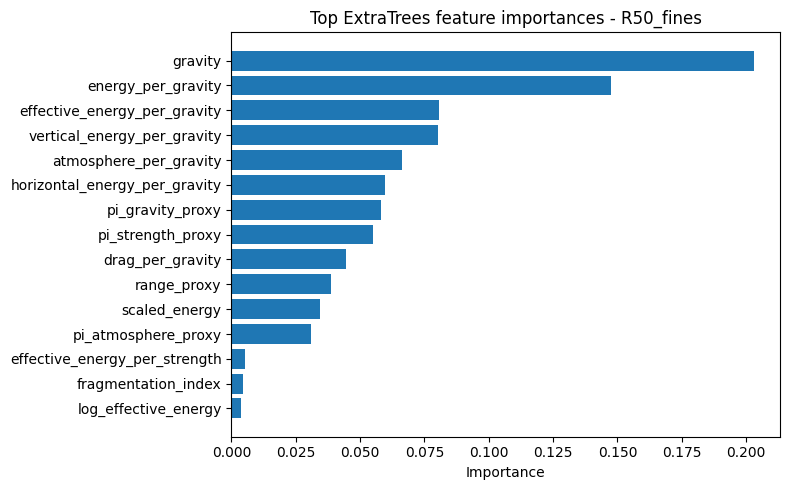


Top feature importances for R50_oversize | feature set: extended_plus_regimes


,feature,importance,target,feature_set
5,gravity,0.166059,R50_oversize,extended_plus_regimes
24,energy_per_gravity,0.127630,R50_oversize,extended_plus_regimes
25,effective_energy_per_gravity,0.082277,R50_oversize,extended_plus_regimes
31,atmosphere_per_gravity,0.079179,R50_oversize,extended_plus_regimes
27,vertical_energy_per_gravity,0.076632,R50_oversize,extended_plus_regimes
26,horizontal_energy_per_gravity,0.070869,R50_oversize,extended_plus_regimes
29,drag_per_gravity,0.062050,R50_oversize,extended_plus_regimes
37,range_proxy,0.044536,R50_oversize,extended_plus_regimes
35,scaled_energy,0.041345,R50_oversize,extended_plus_regimes
32,pi_gravity_proxy,0.040315,R50_oversize,extended_plus_regimes


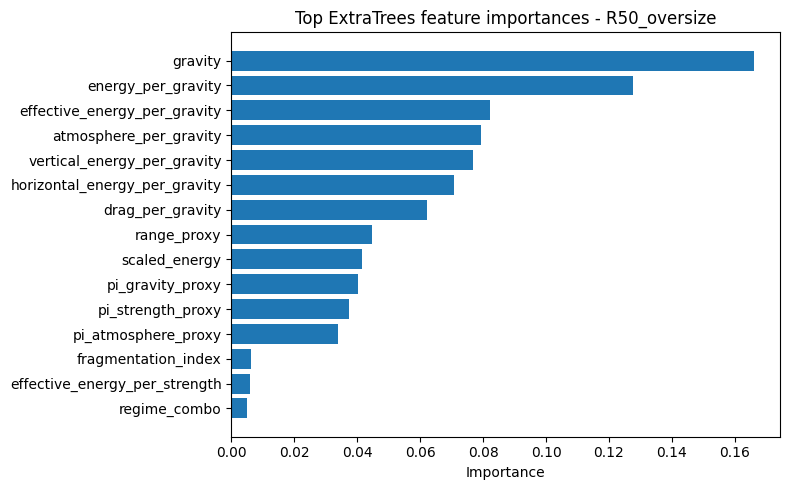

In [20]:
feature_importance_tables = {}

for target in target_cols:
    feature_set_name = best_feature_set_by_target[target]
    features = get_feature_list_for_target_and_set(target, feature_set_name)

    model = build_extratrees_model(random_state=42)
    model.fit(X_fe_train[features], y[target])

    importance_df = pd.DataFrame({
        "feature": features,
        "importance": model.feature_importances_,
        "target": target,
        "feature_set": feature_set_name,
    }).sort_values("importance", ascending=False)

    feature_importance_tables[target] = importance_df

    print(f"\nTop feature importances for {target} | feature set: {feature_set_name}")
    display(importance_df.head(20))

    plt.figure(figsize=(8, 5))
    top_df = importance_df.head(15).iloc[::-1]
    plt.barh(top_df["feature"], top_df["importance"])
    plt.title(f"Top ExtraTrees feature importances - {target}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

all_importance_df = pd.concat(feature_importance_tables.values(), ignore_index=True)

## 20. Train Final Models and Create Submission

This trains one model per target using its selected feature set.  
The submission file is saved in `outputs/submissions`.

In [21]:
final_test_predictions = pd.DataFrame()
final_models = {}

for target in target_cols:
    feature_set_name = best_feature_set_by_target[target]
    features = get_feature_list_for_target_and_set(target, feature_set_name)

    model = build_extratrees_model(random_state=2026)
    model.fit(X_fe_train[features], y[target])

    pred = model.predict(X_fe_test[features])
    pred = clip_predictions(pred, target)

    final_test_predictions[target] = pred
    final_models[target] = {
        "model": model,
        "features": features,
        "feature_set": feature_set_name,
    }

submission = pd.DataFrame({
    "scenario_id": np.arange(len(X_fe_test)),
})

for target in target_cols:
    submission[target] = final_test_predictions[target]

submission_path = SUBMISSIONS_DIR / "prediction_submission_extratrees_target_specific_controlled.csv"
submission.to_csv(submission_path, index=False)

print("Saved submission:", submission_path)
display(submission.head())
display(submission.describe().T)

Saved submission: /home/alouiyaz/projects/boom-challenge-ejecta-prediction/outputs/submissions/prediction_submission_extratrees_target_specific_controlled.csv


,scenario_id,P80,fines_frac,oversize_frac,R95,R50_fines,R50_oversize
0,0,120.633958,0.114141,0.197574,693.701149,688.962722,312.633772
1,1,113.270502,0.049900,0.158901,209.355659,220.557055,102.832346
2,2,149.558883,0.107470,0.394286,774.495382,776.232036,343.173645
3,3,160.763894,0.010444,0.519968,493.913510,573.190353,259.020259
4,4,137.578598,0.048020,0.343671,201.151561,229.935327,94.900583


,count,mean,std,min,25%,50%,75%,max
scenario_id,492.0,245.500000,142.172431,0.000000,122.750000,245.500000,368.250000,491.000000
P80,492.0,154.735808,29.705780,78.983573,130.860144,152.605676,174.030849,220.940290
fines_frac,492.0,0.047676,0.051903,0.002153,0.007865,0.020315,0.080693,0.237090
oversize_frac,492.0,0.448337,0.190245,0.034243,0.289475,0.435492,0.597142,0.809166
R95,492.0,286.881117,227.125404,49.120191,109.530358,174.682430,468.709076,939.948499
R50_fines,492.0,322.661219,228.890374,63.402939,143.203550,203.708150,558.377605,828.184136
R50_oversize,492.0,141.234934,104.958556,27.153034,59.703665,86.301562,249.562896,398.171362


## 21. Save Modeling Artifacts

These CSV files make it easier to compare future models against this ExtraTrees baseline.

In [22]:
comparison_results.to_csv(PROCESSED_DIR / "extratrees_feature_set_comparison.csv", index=False)
selected_metrics_df.to_csv(PROCESSED_DIR / "extratrees_selected_metrics_by_target.csv", index=False)
error_summary_df.to_csv(PROCESSED_DIR / "extratrees_error_summary_by_target.csv", index=False)
gravity_error_df.to_csv(PROCESSED_DIR / "extratrees_error_by_gravity.csv", index=False)
constraint_zone_summary.to_csv(PROCESSED_DIR / "extratrees_constraint_zone_summary.csv", index=False)
constraint_zone_error_df.to_csv(PROCESSED_DIR / "extratrees_constraint_zone_errors.csv", index=False)
feasibility_diagnostic.to_csv(PROCESSED_DIR / "extratrees_feasibility_diagnostic.csv", index=False)
stress_validation_df.to_csv(PROCESSED_DIR / "extratrees_controlled_stress_validation.csv", index=False)
all_importance_df.to_csv(PROCESSED_DIR / "extratrees_feature_importances.csv", index=False)

best_feature_set_path = PROCESSED_DIR / "extratrees_best_feature_set_by_target.json"
with open(best_feature_set_path, "w") as f:
    json.dump(best_feature_set_by_target, f, indent=2)

print("Saved artifacts to:", PROCESSED_DIR)
print("Saved best feature set map:", best_feature_set_path)

Saved artifacts to: /home/alouiyaz/projects/boom-challenge-ejecta-prediction/data/processed
Saved best feature set map: /home/alouiyaz/projects/boom-challenge-ejecta-prediction/data/processed/extratrees_best_feature_set_by_target.json


## 22. Summary and Next Steps

Key points to inspect after running this notebook:

1. **Best feature set per target**  
   Confirm whether fragmentation targets prefer target-family-specific features and distance targets prefer extended/regime features.

2. **Constraint-zone evaluation**  
   Check whether the model is accurate near `96 <= P80 <= 101` and `R95 <= 175`.

3. **Stress validation**  
   Identify slices where the model fails:
   - low gravity,
   - high energy,
   - high atmosphere,
   - near feasible zone.

4. **Prediction quality**  
   Inspect `Predicted vs True` plots and residual distributions.

Recommended next notebook:

`04_modeling_gradient_boosting.ipynb`

Models to test:

- HistGradientBoostingRegressor
- LightGBM
- XGBoost
- CatBoost

Possible advanced strategies:

- two-stage model for `fines_frac`,
- ensemble of ExtraTrees + Gradient Boosting,
- uncertainty filtering for inverse design,
- Monte Carlo / Optuna search for 20 valid design scenarios.